In [21]:
# Load Dataset
# =====================
import pandas as pd

df = pd.read_csv("Clean_Dataset.csv")
print(df.head())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


In [22]:
# =====================
# Quick EDA with Labels
# =====================
print("Airline Counts:\n", df.airline.value_counts())
print("\nSource City Counts:\n", df.source_city.value_counts())
print("\nDeparture Time Counts:\n", df.departure_time.value_counts())
print("\nArrival Time Counts:\n", df.arrival_time.value_counts())
print("\nNumber of Stops Counts:\n", df.stops.value_counts())
print("\nClass Counts:\n", df["class"].value_counts())

Airline Counts:
 airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

Source City Counts:
 source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

Departure Time Counts:
 departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

Arrival Time Counts:
 arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

Number of Stops Counts:
 stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

Class Counts:
 class
Economy     206666
Business     93487
Name: count, dtype: int64


In [23]:
# Check total missing values per column
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [24]:
# Remove rows with any NaN values
df = df.dropna()

# Check again if any NaN remains
print(df.isna().sum())

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [25]:
print("\nMinimum Duration:", df['duration'].min())
print("Maximum Duration:", df['duration'].max())
print("Median Duration:", df['duration'].median())
print("\nPrice Statistics:\n", df["price"].describe())


Minimum Duration: 0.83
Maximum Duration: 49.83
Median Duration: 11.25

Price Statistics:
 count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


/var/folders/yg/hzn_dgcd4gg0xz3qrfr78d640000gn/T/ipykernel_1044/1354905788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="airline", data=df, order=df.airline.value_counts().index, palette="viridis")


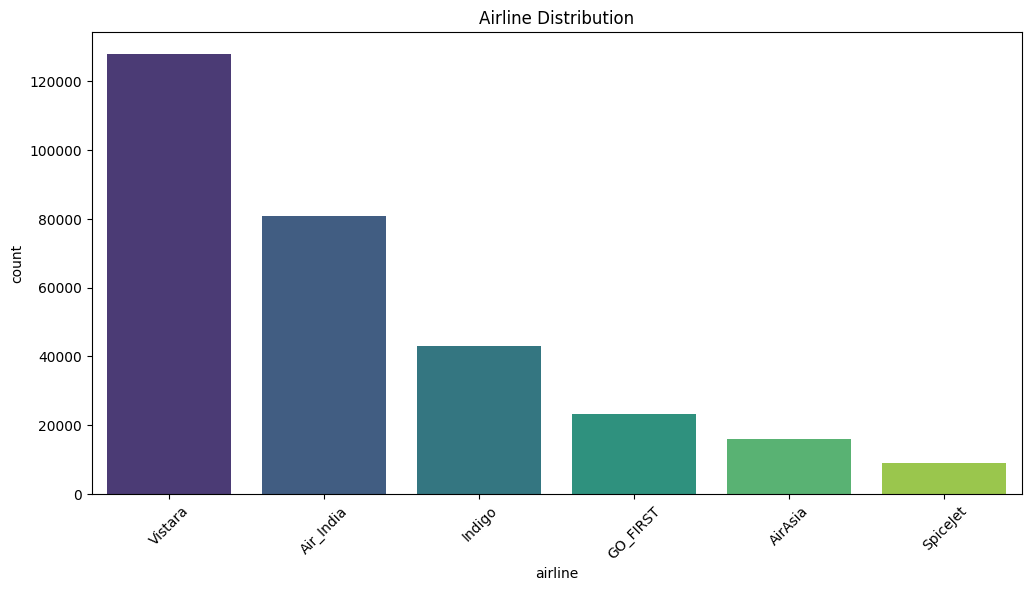

In [26]:
# Plots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(x="airline", data=df, order=df.airline.value_counts().index, palette="viridis")
plt.xticks(rotation=45)
plt.title("Airline Distribution")
plt.show()

In [27]:
# =====================
# Preprocessing
# =====================
# Drop unnecessary columns
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1)

# Encode class (Business=1, Economy=0)
df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)

# Encode stops as numeric
df['stops'] = pd.factorize(df['stops'])[0]

# One-hot encoding (dummy variables) for categorical columns
df = df.join(pd.get_dummies(df['airline'], prefix='airline')).drop('airline', axis=1)
df = df.join(pd.get_dummies(df['source_city'], prefix='source')).drop('source_city', axis=1)
df = df.join(pd.get_dummies(df['destination_city'], prefix='dest')).drop('destination_city', axis=1)
df = df.join(pd.get_dummies(df['arrival_time'], prefix='arrival')).drop('arrival_time', axis=1)
df = df.join(pd.get_dummies(df['departure_time'], prefix='departure')).drop('departure_time', axis=1)

# Convert all boolean columns (True/False) to 1/0
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()


,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [28]:
# Train-Test Split
# =====================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    if name in ["Random Forest"]:  # no scaling needed
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:  # use scaled data
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    print(f"----- {name} -----")
    print(f"R² Score: {r2_score(y_test, preds):.4f}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, preds):.4f}")
    print(f"Root Mean Squared Error (RMSE): {math.sqrt(mean_squared_error(y_test, preds)):.4f}\n")


----- Linear Regression -----
R² Score: 0.9099
Mean Absolute Error (MAE): 4500.7125
Root Mean Squared Error (RMSE): 6814.9356

----- KNN -----
R² Score: 0.9687
Mean Absolute Error (MAE): 1858.3120
Root Mean Squared Error (RMSE): 4019.1373

----- Random Forest -----
R² Score: 0.9849
Mean Absolute Error (MAE): 1077.3535
Root Mean Squared Error (RMSE): 2787.2615



In [31]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)  # use unscaled data

# Predictions
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

In [32]:
# Metrics
train_rmse = math.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = math.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

Train RMSE: 1130.1134423169738
Test RMSE: 2782.3621052029207
R2: 0.9849819493677799
MAE: 1077.323818126772


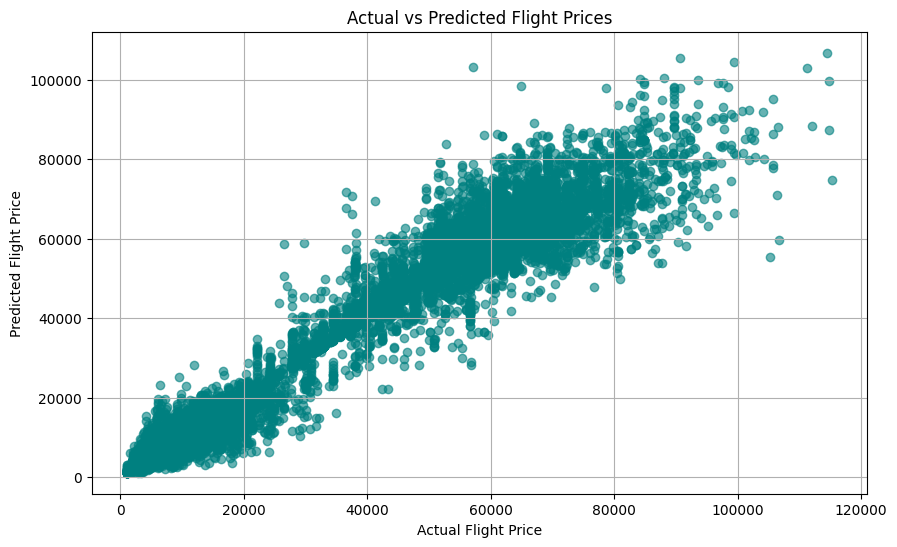

In [33]:
# Scatter plot: Actual vs Predicted Prices
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='teal')
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Actual vs Predicted Flight Prices')
plt.grid(True)
plt.show()

In [34]:
# Feature importance
feature_importances = pd.Series(reg.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

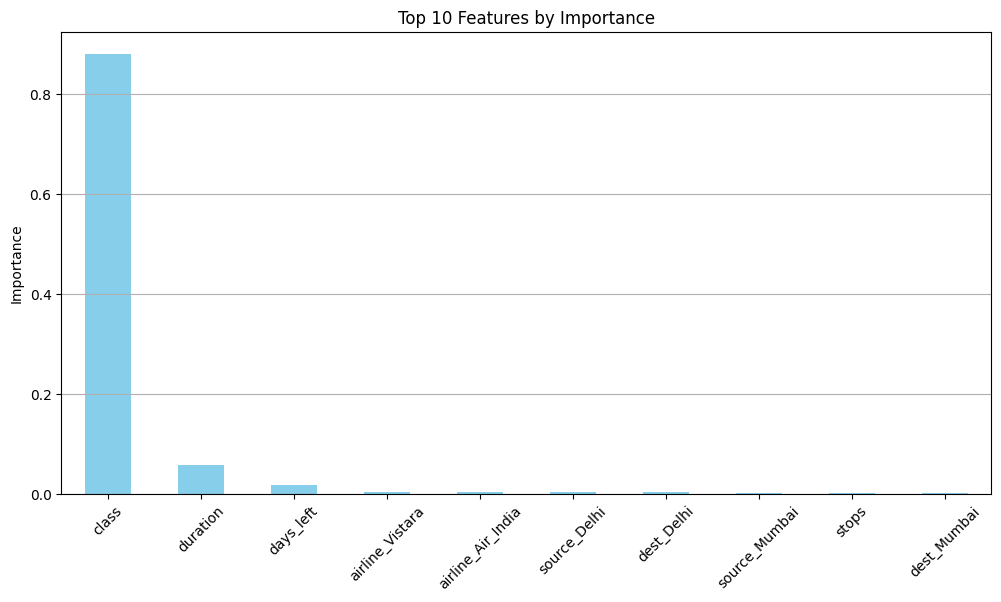

In [35]:
plt.figure(figsize=(12,6))
top_features.plot(kind='bar', color='skyblue')
plt.ylabel('Importance')
plt.title('Top 10 Features by Importance')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [36]:
# Quick summary of price and days_left
print("Price Summary:\n", df['price'].describe())
print("\nDays Left Summary:\n", df['days_left'].describe())

Price Summary:
 count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

Days Left Summary:
 count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

# Minimal parameter grid (only best params candidates)
param_grid = {
    'n_estimators': [200],          # fixed at 200
    'max_depth': [None],            # best found earlier
    'min_samples_split': [5],       # best found earlier
    'min_samples_leaf': [2],        # best found earlier
    'max_features': [None]          # best found earlier
}

# Initialize Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Grid Search with 3-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best estimator and parameters
best_rf = grid_search.best_estimator_
print("\nBest Params (Grid Search):", grid_search.best_params_)

# Evaluate on test data
y_pred_grid = best_rf.predict(X_test)
print("\nGrid Search Random Forest Results:")
print('R2:', r2_score(y_test, y_pred_grid))
print('MAE:', mean_absolute_error(y_test, y_pred_grid))
print('RMSE:', math.sqrt(mean_squared_error(y_test, y_pred_grid)))



Best Params (Grid Search): {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Grid Search Random Forest Results:
R2: 0.9859905510935153
MAE: 1091.7098798512468
RMSE: 2687.3076812605004


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

# Reduced parameter distribution
param_dist = {
    'n_estimators': [100, 200],        # keep small set
    'max_depth': [None, 20],           # shallow vs unlimited
    'min_samples_split': [2, 5],       # default vs stricter
    'min_samples_leaf': [1, 2],        # default vs slightly larger
    'max_features': ['sqrt', None]     # two safe options
}

# Randomized Search (sample only 4 random combos)
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=4,          # fewer random draws
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)
best_random = random_search.best_estimator_

print("\nBest Params (Random Search):", random_search.best_params_)

# Evaluate
y_pred_random = best_random.predict(X_test)
print("\nRandomized Search Random Forest Results:")
print('R2:', r2_score(y_test, y_pred_random))
print('MAE:', mean_absolute_error(y_test, y_pred_random))
print('RMSE:', math.sqrt(mean_squared_error(y_test, y_pred_random)))



Best Params (Random Search): {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}

Randomized Search Random Forest Results:
R2: 0.9859905510935153
MAE: 1091.7098798512468
RMSE: 2687.3076812605


In [42]:
# PCA Analysis
# =====================
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPCA Results:")
print(f"Original features: {X.shape[1]} -> PCA features: {X_train_pca.shape[1]}")


PCA Results:
Original features: 34 -> PCA features: 26


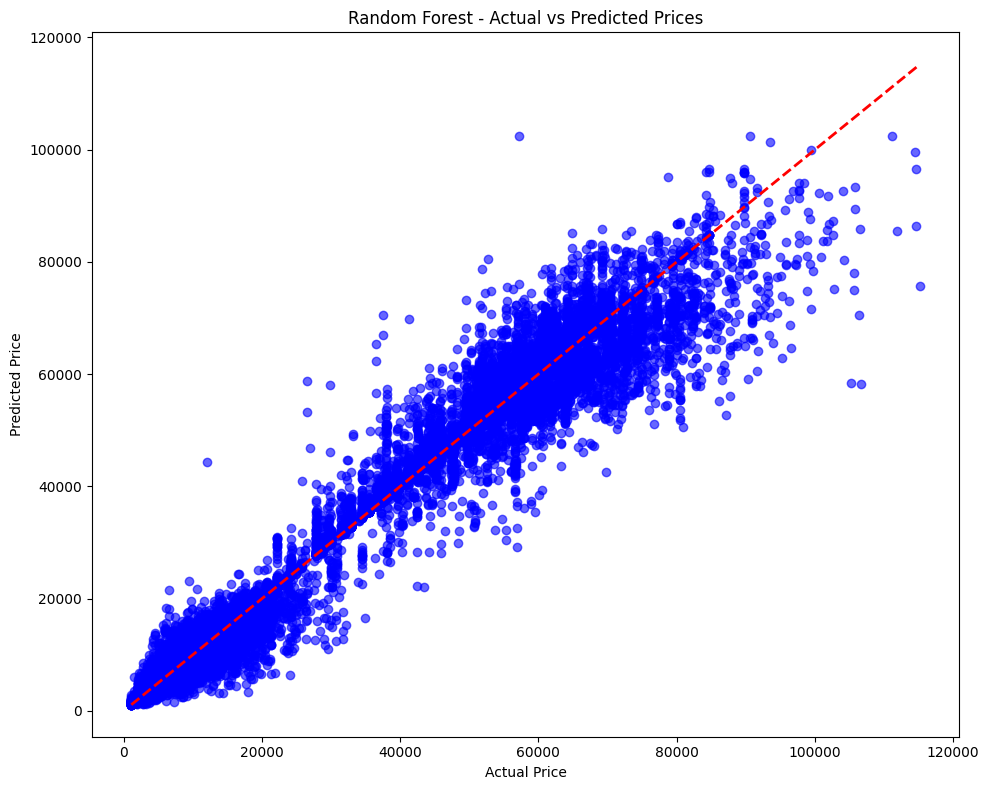

In [45]:
# Make predictions with best model
best_preds = best_rf.predict(X_test)

# Actual vs Predicted plot
plt.figure(figsize=(10,8))
plt.scatter(y_test, best_preds, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest - Actual vs Predicted Prices")
plt.tight_layout()
plt.show()


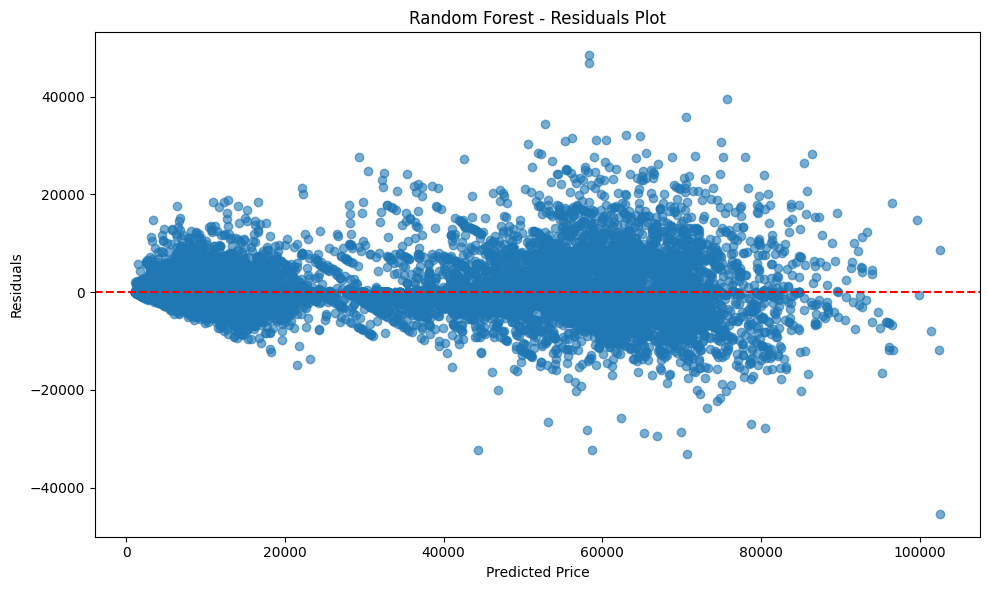

In [47]:
# Residuals plot
residuals = y_test - best_preds
plt.figure(figsize=(10, 6))
plt.scatter(best_preds, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Random Forest - Residuals Plot")
plt.tight_layout()
plt.show()


In [52]:
# Final Summary for Tuned Random Forest
import math
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)

best_model_name = "Random Forest (Tuned)"

# Evaluate on test set
r2 = r2_score(y_test, y_pred_grid)
rmse = math.sqrt(mean_squared_error(y_test, y_pred_grid))
mae = mean_absolute_error(y_test, y_pred_grid)

print(f"\nBest performing model: {best_model_name}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")




FINAL MODEL SUMMARY

Best performing model: Random Forest (Tuned)
R2 Score: 0.9860
RMSE: 2687.3077
MAE: 1091.7099


In [ ]:
import pickle

# Save the trained model
pickle.dump(best_rf, open('model.pkl', 'wb'))

In [55]:
# Load the model later
model_loaded = pickle.load(open('model.pkl', 'rb'))

# Example new sample (replace with actual feature values)
new_sample = pd.DataFrame([{
    'stops': 1,
    'days_left': 5,
    'duration': 120,
    # include all one-hot encoded features like airline columns
    'airline_Air India': 0,
    'airline_IndiGo': 1,
    'airline_SpiceJet': 0,
    # ... all other one-hot encoded columns ...
}])

# Ensure columns match training data
new_sample = new_sample.reindex(columns=X_train.columns, fill_value=0)

# Predict
predicted_price = model_loaded.predict(new_sample)
print("Predicted Flight Price:", round(predicted_price[0], 2))

Predicted Flight Price: 7656.24


## Model Compression

In [1]:
import joblib

# Save with compression
joblib.dump(best_rf, 'model_compressed.pkl', compress=3)  # compress=1~9


NameError: name 'best_rf' is not defined

In [ ]:
import joblib
import pandas as pd

# Save the trained model with compression
joblib.dump(best_rf, 'model_compressed.pkl', compress=3)

# Load the model later
model_loaded = joblib.load('model_compressed.pkl')

# Example new sample
new_sample = pd.DataFrame([{
    'stops': 1,
    'days_left': 5,
    'duration': 120,
    'airline_Air India': 0,
    'airline_IndiGo': 1,
    'airline_SpiceJet': 0,
    # ... all other one-hot encoded columns ...
}])

# Ensure columns match training data
new_sample = new_sample.reindex(columns=X_train.columns, fill_value=0)

# Predict
predicted_price = model_loaded.predict(new_sample)
print("Predicted Flight Price:", round(predicted_price[0], 2))
